In [3]:
# Mata Kuliah Data Mining
# Kelompok 6 - SI4802
# Anggota:
# 102022430036 - Muhammad Daffa Izzati
# 102022400329 - Muhammad Daffa Reifansya
# 102022400325 - Kevin Muhammad Althaf
# 102022430069 - Sekar Erliana Putri

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.model_selection import GridSearchCV
import joblib

In [5]:
# Read Dari Kaggle
# df = pd.read_csv('/kaggle/input/datasets/arjunbhasin2013/ccdata/CC GENERAL.csv')

# Read dari VSCODE
df = pd.read_csv('CC GENERAL.csv')

# EDA

In [6]:
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [7]:
print(f"Jumlah Record (Baris) : {df.shape[0]}")
print(f"Jumlah Variabel (Kolom): {df.shape[1]}\n")

Jumlah Record (Baris) : 8950
Jumlah Variabel (Kolom): 18



In [8]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

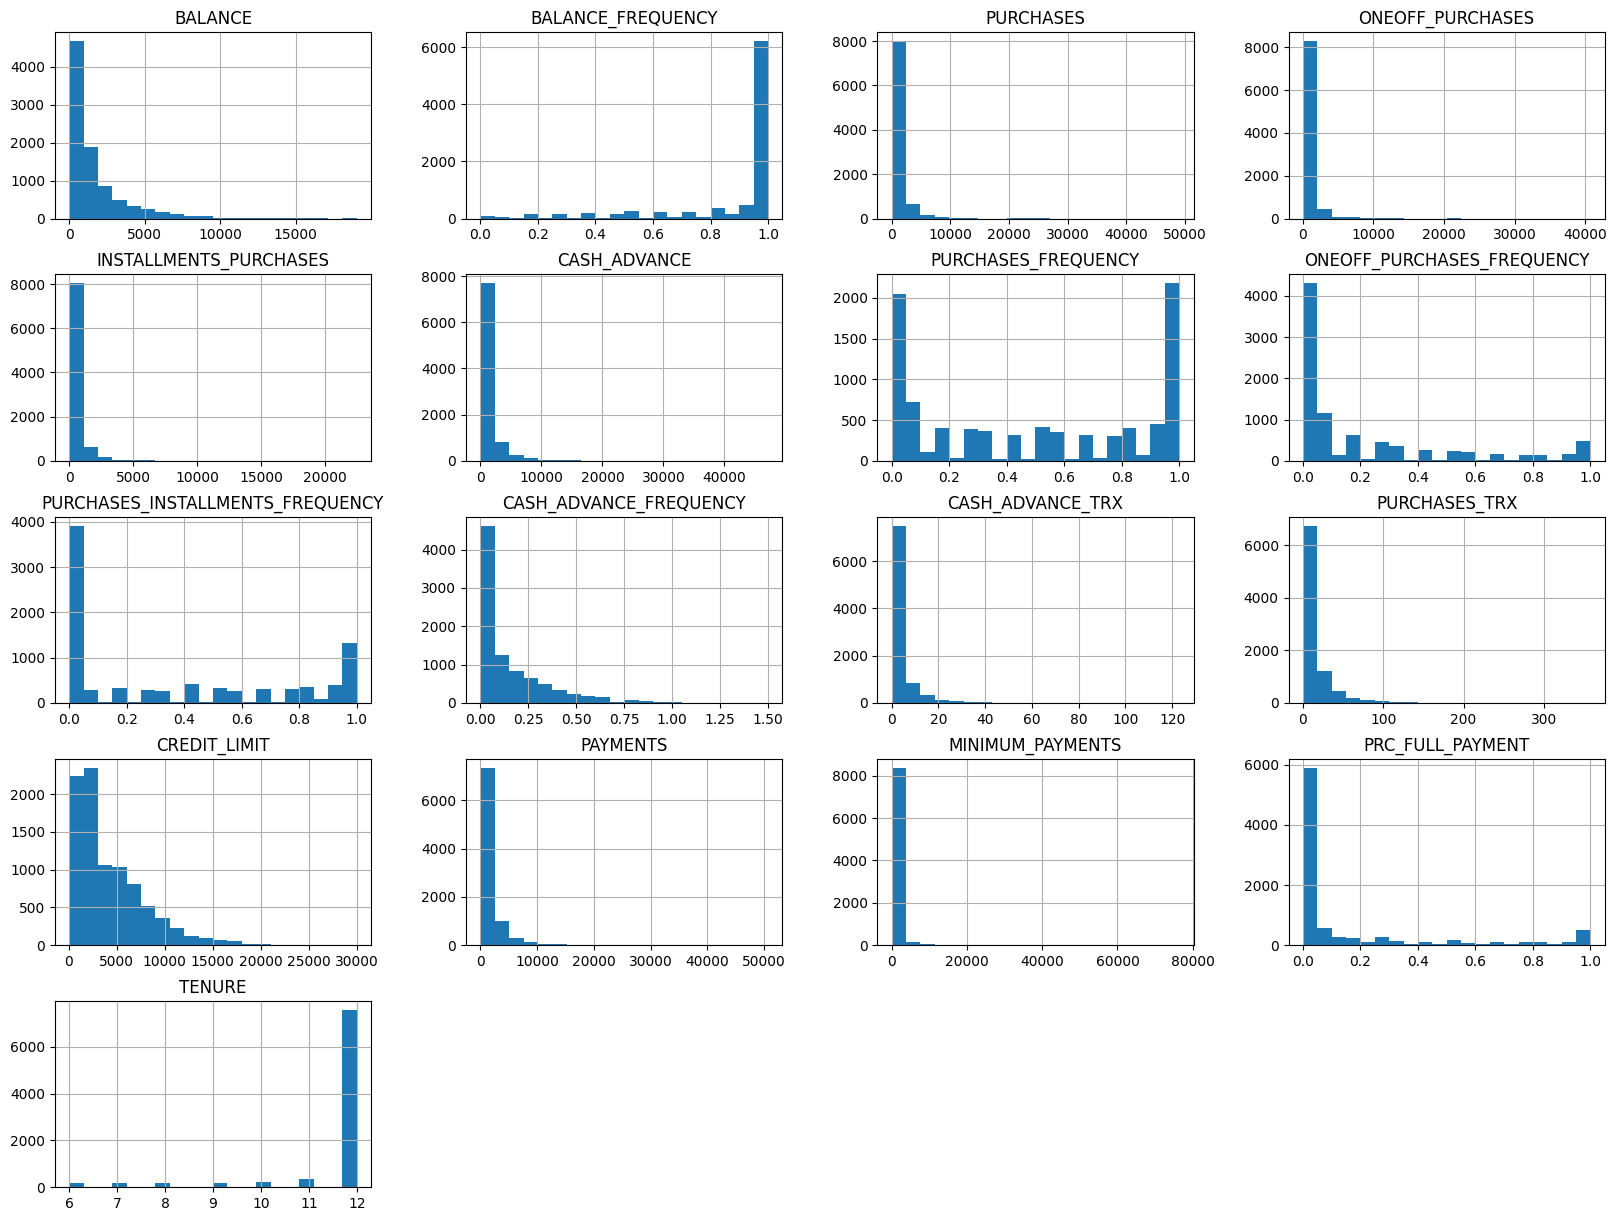

In [10]:
df.hist(bins=20, figsize=(20, 15))
plt.show()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

# DATA PREPARATION 

In [13]:
df_prepared = df.drop(columns=['CUST_ID'])

In [14]:
display(df_prepared)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [15]:
df_prepared['MINIMUM_PAYMENTS'] = df_prepared['MINIMUM_PAYMENTS'].fillna(df_prepared['MINIMUM_PAYMENTS'].median())
df_prepared['CREDIT_LIMIT'] = df_prepared['CREDIT_LIMIT'].fillna(df_prepared['CREDIT_LIMIT'].median())

In [16]:
df_prepared.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

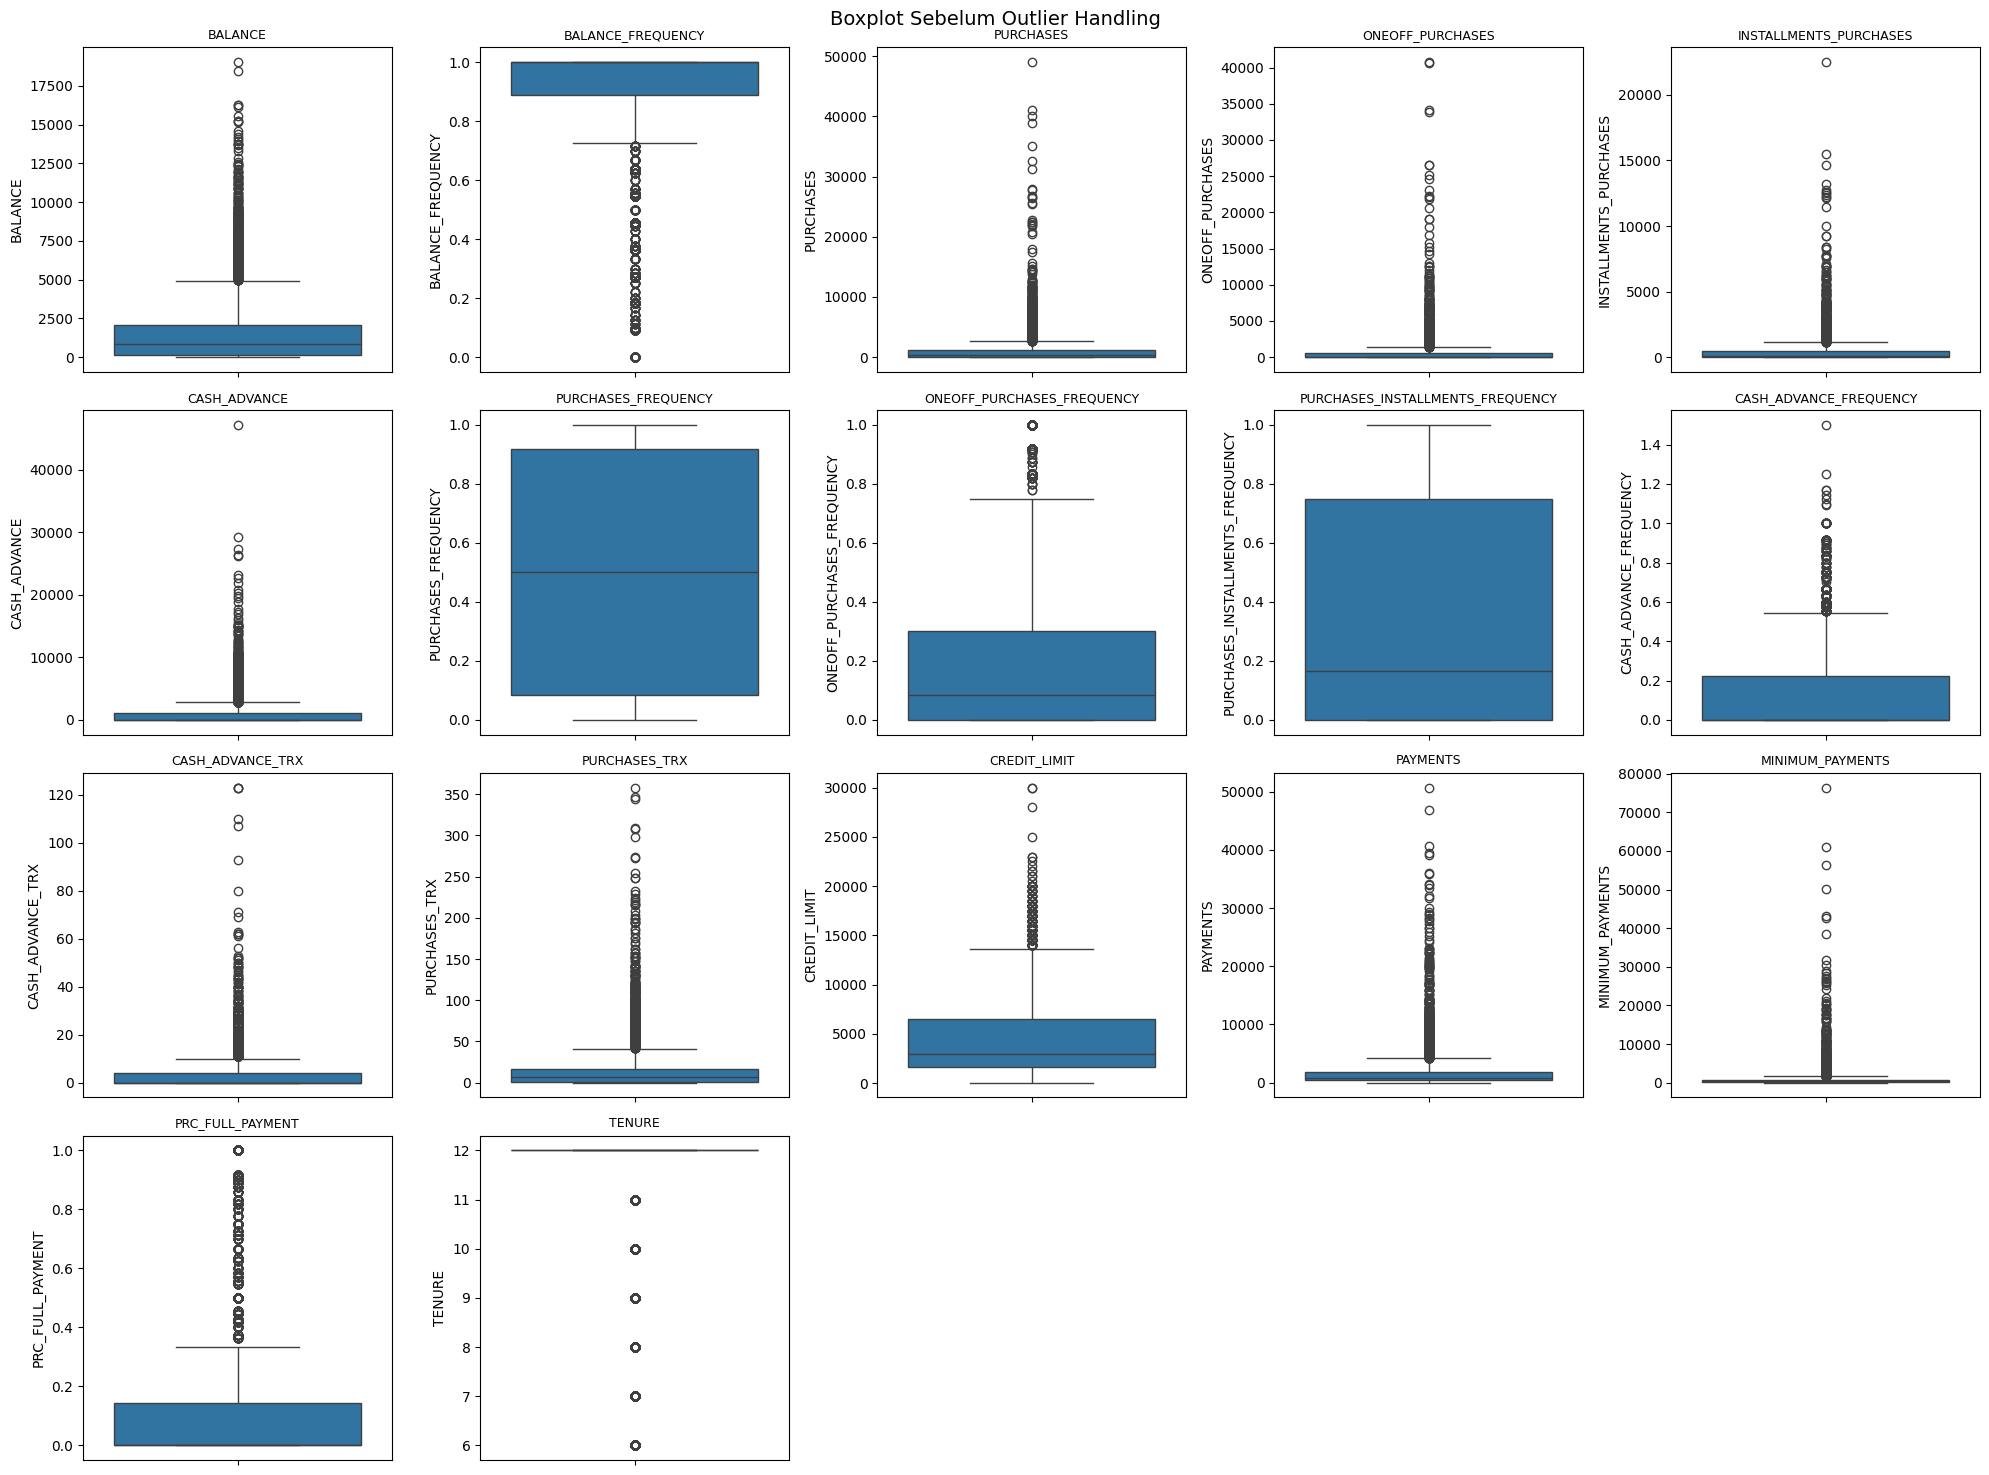

In [17]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(df_prepared.columns):
    plt.subplot(4, 5, i + 1)
    sns.boxplot(y=df_prepared[col])
    plt.title(col, fontsize=9)
plt.suptitle('Boxplot Sebelum Outlier Handling', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
df_clean = df_prepared.copy()

for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    print(f"{col}: {outlier_count} outlier ditemukan")
    
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

print(f"\nShape sebelum: {df_prepared.shape}")
print(f"Shape sesudah: {df_clean.shape}")

BALANCE: 695 outlier ditemukan
BALANCE_FREQUENCY: 1493 outlier ditemukan
PURCHASES: 808 outlier ditemukan
ONEOFF_PURCHASES: 1013 outlier ditemukan
INSTALLMENTS_PURCHASES: 867 outlier ditemukan
CASH_ADVANCE: 1030 outlier ditemukan
PURCHASES_FREQUENCY: 0 outlier ditemukan
ONEOFF_PURCHASES_FREQUENCY: 782 outlier ditemukan
PURCHASES_INSTALLMENTS_FREQUENCY: 0 outlier ditemukan
CASH_ADVANCE_FREQUENCY: 525 outlier ditemukan
CASH_ADVANCE_TRX: 804 outlier ditemukan
PURCHASES_TRX: 766 outlier ditemukan
CREDIT_LIMIT: 248 outlier ditemukan
PAYMENTS: 808 outlier ditemukan
MINIMUM_PAYMENTS: 909 outlier ditemukan
PRC_FULL_PAYMENT: 1474 outlier ditemukan
TENURE: 1366 outlier ditemukan

Shape sebelum: (8950, 17)
Shape sesudah: (8950, 17)


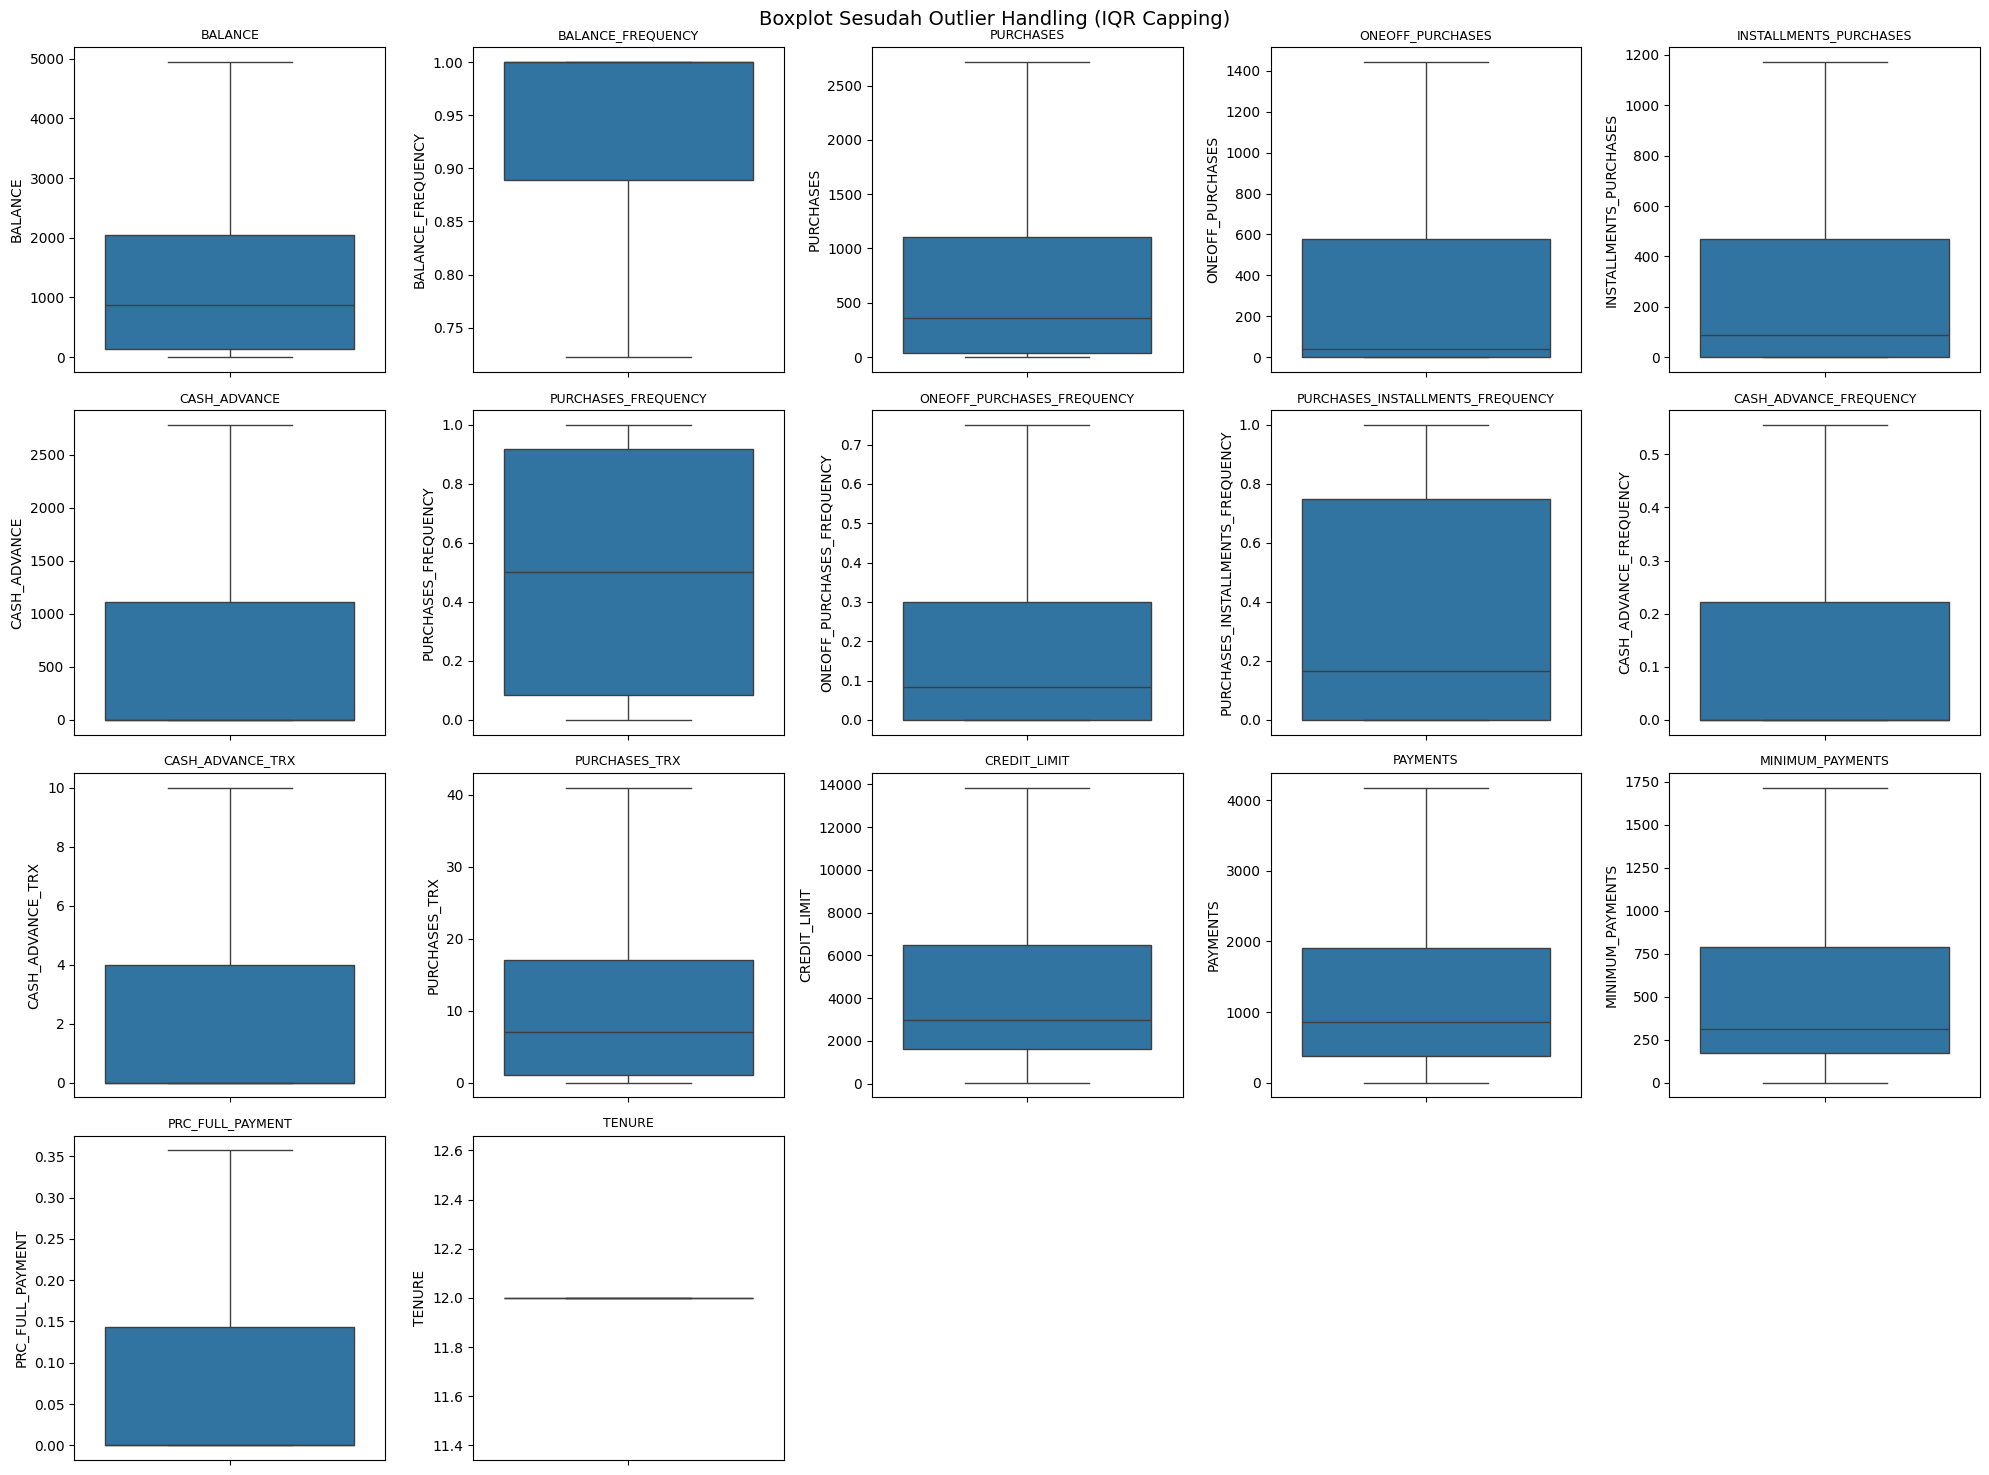

In [19]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(df_clean.columns):
    plt.subplot(4, 5, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(col, fontsize=9)
plt.suptitle('Boxplot Sesudah Outlier Handling (IQR Capping)', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_prepared.columns)

In [21]:
display(df_scaled.head())

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.877821,-1.021875,-0.729687,-0.692383,-0.505216,-0.673507,-0.806490,-0.722749,-0.707313,-0.730084,-0.697293,-0.737970,-1.010503,-0.899859,-0.784078,-0.629277,0.0
1,1.178546,-0.202708,-0.838160,-0.692383,-0.746029,2.115343,-1.221758,-0.722749,-0.916995,0.717792,0.473089,-0.891333,0.762757,2.165375,0.968887,0.973961,0.0
2,0.718487,0.616459,0.040957,0.818320,-0.746029,-0.673507,1.269843,2.210909,-0.916995,-0.730084,-0.697293,0.028848,0.910528,-0.569653,0.132544,-0.629277,0.0
3,0.179623,-1.886552,0.866246,2.128108,-0.746029,-0.467401,-1.014125,-0.396788,-0.916995,-0.247460,-0.404697,-0.814651,0.910528,-1.058417,-0.459290,-0.629277,0.0
4,-0.372561,0.616459,-0.819967,-0.661121,-0.746029,-0.673507,-1.014125,-0.396788,-0.916995,-0.730084,-0.697293,-0.814651,-0.951394,-0.525443,-0.586234,-0.629277,0.0


In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

display(pd.DataFrame(X_pca, columns=['PCA 1', 'PCA 2']))

,PCA 1,PCA 2
0,-1.649671,-2.413427
1,-2.208957,2.305566
2,1.167597,0.296230
3,-0.491749,-0.561124
4,-1.666534,-1.621697
...,...,...
8945,0.658859,-2.528178
8946,0.234144,-1.933175
8947,-0.123050,-2.787397
8948,-2.088616,-2.285744


# MODELLING

### Clustering

In [23]:
inertias = []
K = range(1, 10)

for k in K:
    k_means = KMeans(n_clusters=k, random_state=42)
    k_means.fit(X_pca)
    inertias.append(k_means.inertia_)

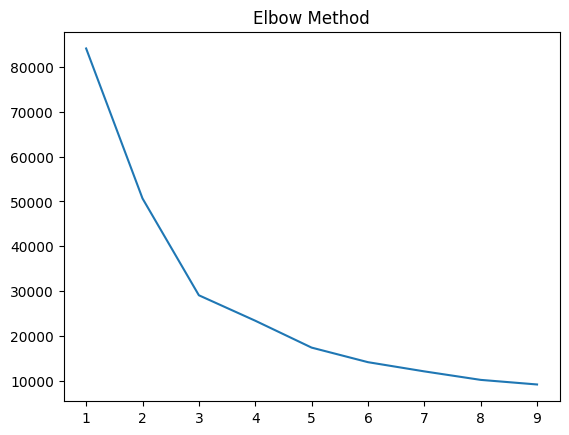

In [24]:
plt.plot(K, inertias)
plt.title('Elbow Method')
plt.show()

In [25]:
k_means_5 = KMeans(n_clusters=5, random_state=42)
labels_5 = k_means_5.fit_predict(X_pca)

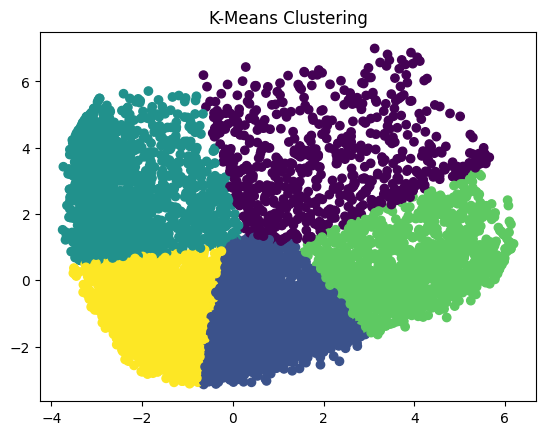

In [26]:
plt.scatter(x=X_pca[:, 0], y=X_pca[:, 1], c=labels_5)
plt.title('K-Means Clustering')
plt.show()

In [27]:
silhouette_score(X_pca, labels_5)

0.3929476067261817

In [28]:
sil_scores = []
K = range(2, 10)

for k in K:
    k_means = KMeans(n_clusters=k, random_state=42)
    labels = k_means.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

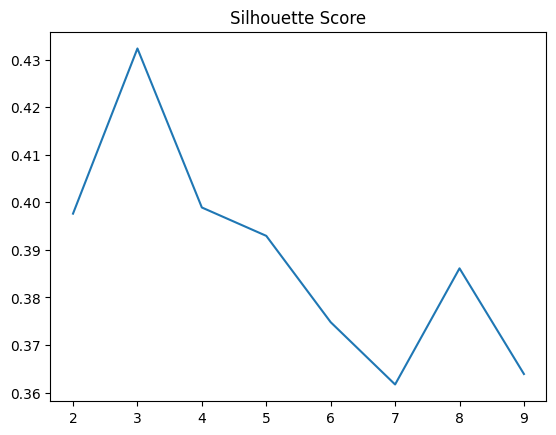

In [29]:
plt.plot(K, sil_scores)
plt.title('Silhouette Score')
plt.show()

In [30]:
k_means_final = KMeans(n_clusters=2, random_state=42)
labels_final = k_means_final.fit_predict(X_pca)

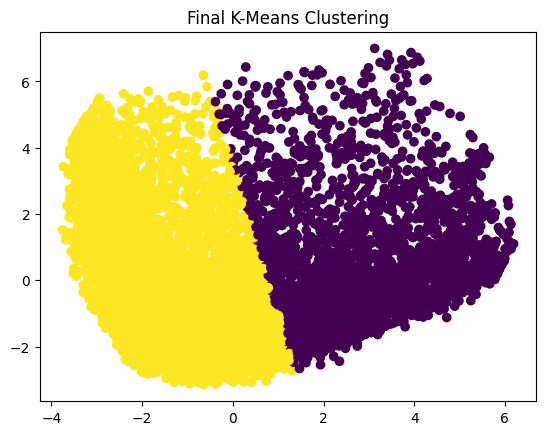

In [31]:
plt.scatter(x=X_pca[:, 0], y=X_pca[:, 1], c=labels_final)
plt.title('Final K-Means Clustering')
plt.show()

In [32]:
df_clean['Kategori_Cluster'] = labels_final

display(df_clean.head(10))

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Kategori_Cluster
0,40.900749,0.818182,95.4000,0.0000,95.40000,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.0000,0.0000,0.00000,2784.552848,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,1.000000,773.1700,773.1700,0.00000,0.000000,1.000000,0.750000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.722223,1499.0000,1443.5125,0.00000,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.0000,16.0000,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1
5,1809.828751,1.000000,1333.2800,0.0000,1171.59375,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,1715.497271,0.000000,12,0
6,627.260806,1.000000,2715.8725,1443.5125,688.38000,0.000000,1.000000,0.750000,1.000000,0.000000,0,41,13500.0,4177.921543,198.065894,0.357143,12,0
7,1823.652743,1.000000,436.2000,0.0000,436.20000,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12,1
8,1014.926473,1.000000,861.4900,661.4900,200.00000,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12,1
9,152.225975,0.722223,1281.6000,1281.6000,0.00000,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12,1


### Classification

In [33]:
df_clean['Kategori_Cluster'] = labels_final
display(df_clean.head(10))

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Kategori_Cluster
0,40.900749,0.818182,95.4000,0.0000,95.40000,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.0000,0.0000,0.00000,2784.552848,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,1.000000,773.1700,773.1700,0.00000,0.000000,1.000000,0.750000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.722223,1499.0000,1443.5125,0.00000,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.0000,16.0000,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1
5,1809.828751,1.000000,1333.2800,0.0000,1171.59375,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,1715.497271,0.000000,12,0
6,627.260806,1.000000,2715.8725,1443.5125,688.38000,0.000000,1.000000,0.750000,1.000000,0.000000,0,41,13500.0,4177.921543,198.065894,0.357143,12,0
7,1823.652743,1.000000,436.2000,0.0000,436.20000,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12,1
8,1014.926473,1.000000,861.4900,661.4900,200.00000,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12,1
9,152.225975,0.722223,1281.6000,1281.6000,0.00000,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12,1


In [34]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [35]:
X = df_clean.drop(columns='Kategori_Cluster')
y = df_clean['Kategori_Cluster']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [37]:
scaler2 = StandardScaler()
X_train = scaler2.fit_transform(X_train)
X_test = scaler2.transform(X_test)

## Logistic Regression

In [38]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
y_pred_logreg = logreg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_logreg)
conf_matrix = confusion_matrix(y_test, y_pred_logreg)
target_names = ['Class 0', 'Class 1']
class_report = classification_report(y_test, y_pred_logreg, target_names=target_names)

print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print("Classification Report:")
print(class_report)

Accuracy Score: 0.9977653631284916
Confusion Matrix:
[[ 596    4]
 [   0 1190]]
Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      0.99      1.00       600
     Class 1       1.00      1.00      1.00      1190

    accuracy                           1.00      1790
   macro avg       1.00      1.00      1.00      1790
weighted avg       1.00      1.00      1.00      1790



In [40]:
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid_logreg,
    cv=5,
    scoring='accuracy'
)

grid_search_logreg.fit(X_train, y_train)

c:\Users\Izzati\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Izzati\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Izzati\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Izzati\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Izzati\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means

,estimator,LogisticRegression()
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [41]:
y_pred_logreg = grid_search_logreg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_logreg)
conf_matrix = confusion_matrix(y_test, y_pred_logreg)
class_report = classification_report(y_test, y_pred_logreg, target_names=target_names)

print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print("Classification Report:")
print(class_report)

print("Parameter terbaik: ", grid_search_logreg.best_params_)
print("Skor akurasi terbaik: ", grid_search_logreg.best_score_)

Accuracy Score: 0.9994413407821229
Confusion Matrix:
[[ 600    0]
 [   1 1189]]
Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       600
     Class 1       1.00      1.00      1.00      1190

    accuracy                           1.00      1790
   macro avg       1.00      1.00      1.00      1790
weighted avg       1.00      1.00      1.00      1790

Parameter terbaik:  {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Skor akurasi terbaik:  0.9990223463687151


## Naive Bayes

In [42]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [43]:
y_pred_gnb = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gnb)
conf_matrix = confusion_matrix(y_test, y_pred_gnb)
target_names = ['Class 0', 'Class 1']
class_report = classification_report(y_test, y_pred_gnb, target_names=target_names)

print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print("Classification Report:")
print(class_report)

Accuracy Score: 0.9614525139664805
Confusion Matrix:
[[ 599    1]
 [  68 1122]]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.90      1.00      0.95       600
     Class 1       1.00      0.94      0.97      1190

    accuracy                           0.96      1790
   macro avg       0.95      0.97      0.96      1790
weighted avg       0.97      0.96      0.96      1790



In [44]:
param_grid_gnb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_search_gnb = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid_gnb,
    cv=5,                 
    scoring='accuracy',   
    verbose=1,
    n_jobs=-1            
)

grid_search_gnb.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,GaussianNB()
,param_grid,{'var_smoothing': array([1.0000...00000000e-09])}
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [45]:
y_pred_gnb = grid_search_gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gnb)
conf_matrix = confusion_matrix(y_test, y_pred_gnb)
class_report = classification_report(y_test, y_pred_gnb, target_names=target_names)

print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print("Classification Report:")
print(class_report)

print("Parameter terbaik: ", grid_search_gnb.best_params_)
print("Skor akurasi terbaik: ", grid_search_gnb.best_score_)

Accuracy Score: 0.9837988826815642
Confusion Matrix:
[[ 584   16]
 [  13 1177]]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.97      0.98       600
     Class 1       0.99      0.99      0.99      1190

    accuracy                           0.98      1790
   macro avg       0.98      0.98      0.98      1790
weighted avg       0.98      0.98      0.98      1790

Parameter terbaik:  {'var_smoothing': np.float64(0.3511191734215131)}
Skor akurasi terbaik:  0.9803072625698324


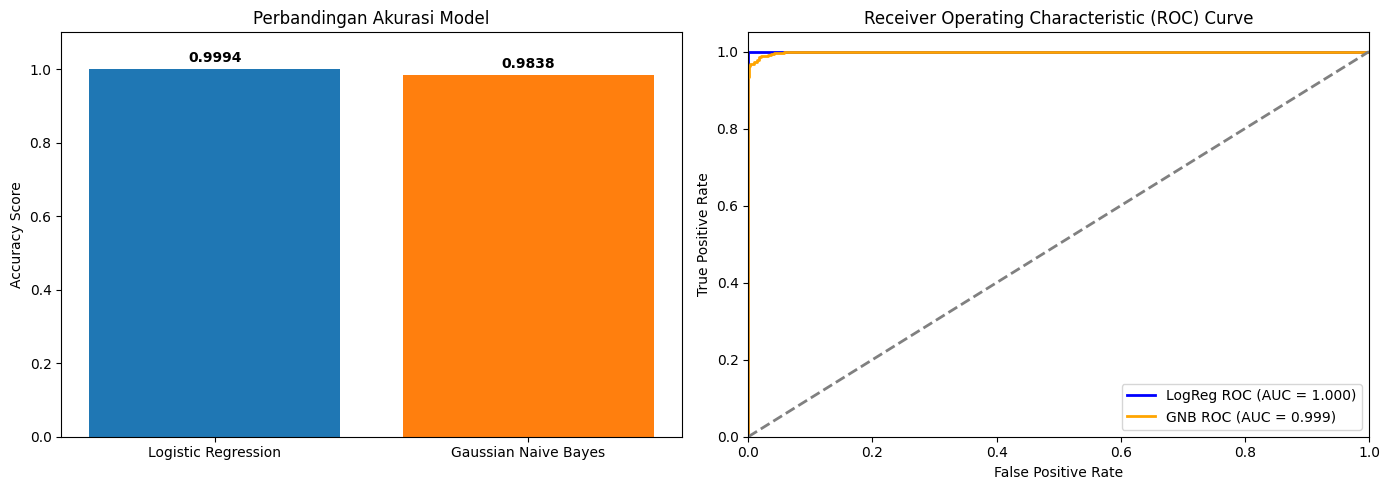

In [46]:
# Dapatkan probabilitas dan prediksi untuk kedua model
y_proba_logreg = grid_search_logreg.predict_proba(X_test)[:, 1]
y_proba_gnb = grid_search_gnb.predict_proba(X_test)[:, 1]

# Hitung Akurasi
acc_logreg = accuracy_score(y_test, y_pred_logreg)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

# --- VISUALISASI 1: Bar Chart Akurasi ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

models = ['Logistic Regression', 'Gaussian Naive Bayes']
accuracies = [acc_logreg, acc_gnb]
colors = ['#1f77b4', '#ff7f0e']

ax[0].bar(models, accuracies, color=colors)
ax[0].set_ylim(0, 1.1)
ax[0].set_title('Perbandingan Akurasi Model')
ax[0].set_ylabel('Accuracy Score')
for i, v in enumerate(accuracies):
    ax[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

# --- VISUALISASI 2: Kurva ROC ---
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_logreg)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_proba_gnb)
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)

ax[1].plot(fpr_log, tpr_log, color='blue', lw=2, label=f'LogReg ROC (AUC = {roc_auc_log:.3f})')
ax[1].plot(fpr_gnb, tpr_gnb, color='orange', lw=2, label=f'GNB ROC (AUC = {roc_auc_gnb:.3f})')
ax[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# DEPLOYMENT

In [47]:
# joblib.dump(scaler2, 'scaler.pkl')
# joblib.dump(grid_search_logreg.best_estimator_, 'logreg_model.pkl')
# joblib.dump(grid_search_gnb.best_estimator_, 'gnb_model.pkl')

In [48]:
# !ngrok config add-authtoken 3DvfEyCRS93bTrynmSXMBTzZV0r_7SHRKTcgG8ukVvhRUW34i

In [49]:
# %%writefile app.py

# import streamlit as st
# import pandas as pd
# import joblib
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import KMeans
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# st.set_page_config(page_title="Credit Card Clustering", page_icon="💳", layout="wide")

# st.title("Dashboard Prediksi Tipe Pengguna Kartu Kredit")
# st.markdown("Aplikasi ini menggunakan model **K-Means Clustering** dan **Logistic Regression** untuk memprediksi kebiasaan transaksi nasabah berdasarkan data historis kartu kredit.")
# # st.markdown("Tugas Besar Data Mining Kelompok 6")
# # st.markdown("Muhammad Daffa Izzati    - 102022430036")
# # st.markdown("Kevin Muhammad Althaf    - 102022400325")
# # st.markdown("Muhammad Daffa Reifansya - 102022400329")
# # st.markdown("Sekar Erliana Putri      - 102022430069")
# st.divider()

# tab1, tab2 = st.tabs(["Form Prediksi", "Visualisasi Kinerja Model"])

# with tab1:
#     st.header("Masukkan Data Nasabah Baru")

#     col1, col2 = st.columns(2)

#     with col1:
#         st.subheader("Informasi Saldo & Pembelian")
#         with st.container(border=True):
#             balance = st.number_input("Jumlah Sisa Saldo (BALANCE)", min_value=0.0, value=1000.0, step=100.0)
#             balance_frequency = st.slider("Frekuensi Saldo (BALANCE_FREQUENCY)", min_value=0.0, max_value=1.0, value=1.0, step=0.05)
#             purchases = st.number_input("Total Pembelian (PURCHASES)", min_value=0.0, value=500.0, step=100.0)
#             oneoff_purchases = st.number_input("Pembelian Sekali Bayar (ONEOFF)", min_value=0.0, value=200.0, step=50.0)
#             installments_purchases = st.number_input("Pembelian Cicilan (INSTALLMENTS)", min_value=0.0, value=300.0, step=50.0)

#             st.markdown("**Intensitas Pembelian**")
#             purchases_frequency = st.slider("Frekuensi Pembelian", min_value=0.0, max_value=1.0, value=0.5, step=0.05)
#             oneoff_purchases_frequency = st.slider("Frekuensi Pembelian Sekali Bayar", min_value=0.0, max_value=1.0, value=0.2, step=0.05)
#             purchases_installments_frequency = st.slider("Frekuensi Pembelian Cicilan", min_value=0.0, max_value=1.0, value=0.4, step=0.05)
#             purchases_trx = st.number_input("Jumlah Transaksi Pembelian (TRX)", min_value=0, value=5, step=1)

#     with col2:
#         st.subheader("Informasi Tunai & Pembayaran")
#         with st.container(border=True):
#             cash_advance = st.number_input("Penarikan Tunai (CASH_ADVANCE)", min_value=0.0, value=0.0, step=100.0)
#             cash_advance_frequency = st.slider("Frekuensi Penarikan Tunai", min_value=0.0, max_value=1.0, value=0.0, step=0.05)
#             cash_advance_trx = st.number_input("Jumlah Transaksi Penarikan (TRX)", min_value=0, value=0, step=1)

#             st.markdown("**Informasi Kredit & Tagihan**")
#             credit_limit = st.number_input("Batas Kredit (CREDIT_LIMIT)", min_value=0.0, value=3000.0, step=500.0)
#             payments = st.number_input("Jumlah Pembayaran (PAYMENTS)", min_value=0.0, value=800.0, step=100.0)
#             minimum_payments = st.number_input("Pembayaran Minimum (MIN_PAYMENTS)", min_value=0.0, value=200.0, step=50.0)
#             prc_full_payment = st.slider("Persentase Pembayaran Penuh", min_value=0.0, max_value=1.0, value=0.1, step=0.05)
#             tenure = st.selectbox("Pilih Tenure:", [6, 7, 8, 9, 10, 11, 12])

#     st.write("")
#     _, col_btn, _ = st.columns([1, 1, 1])
#     with col_btn:
#         submit_button = st.button("Prediksi Cluster Nasabah", use_container_width=True)

#     if submit_button:
#         user_input = pd.DataFrame({
#             'BALANCE': [balance],
#             'BALANCE_FREQUENCY': [balance_frequency],
#             'PURCHASES': [purchases],
#             'ONEOFF_PURCHASES': [oneoff_purchases],
#             'INSTALLMENTS_PURCHASES': [installments_purchases],
#             'CASH_ADVANCE': [cash_advance],
#             'PURCHASES_FREQUENCY': [purchases_frequency],
#             'ONEOFF_PURCHASES_FREQUENCY': [oneoff_purchases_frequency],
#             'PURCHASES_INSTALLMENTS_FREQUENCY': [purchases_installments_frequency],
#             'CASH_ADVANCE_FREQUENCY': [cash_advance_frequency],
#             'CASH_ADVANCE_TRX': [cash_advance_trx],
#             'PURCHASES_TRX': [purchases_trx],
#             'CREDIT_LIMIT': [credit_limit],
#             'PAYMENTS': [payments],
#             'MINIMUM_PAYMENTS': [minimum_payments],
#             'PRC_FULL_PAYMENT': [prc_full_payment],
#             'TENURE': [tenure]
#         })

#         try:
#             scaler = joblib.load('scaler.pkl')
#             logreg_model = joblib.load('logreg_model.pkl')

#             user_input_scaled = scaler.transform(user_input)
#             prediction = logreg_model.predict(user_input_scaled)
#             hasil_prediksi = prediction[0]

#             if hasil_prediksi == 0:
#                 nama_cluster = "Cluster 0: Pengguna Aktif Pembelian (Active Shoppers) 🛒"
#                 deskripsi = "Pengguna ini memiliki kecenderungan untuk sering menggunakan kartu kredit mereka secara langsung untuk berbelanja (transaksi tinggi) dan sangat jarang melakukan penarikan uang tunai."
#             elif hasil_prediksi == 1:
#                 nama_cluster = "Cluster 1: Pengguna Tarik Tunai (Cash Advance Users) 🏧"
#                 deskripsi = "Pengguna ini jarang berbelanja menggunakan kartu kredit, namun sering menggunakannya untuk menarik uang tunai. Mereka cenderung menyisakan saldo tagihan yang tinggi."
#             else:
#                 nama_cluster = f"Cluster {hasil_prediksi}"
#                 deskripsi = ""

#             st.write("---")
#             st.subheader("📈 Hasil Analisis")
#             st.success("**Nasabah ini masuk ke dalam kategori:**")
#             st.metric(label="Prediksi Logistic Regression", value=nama_cluster)
#             st.info(f"**Karakteristik:** {deskripsi}")
#             st.balloons()

#         except FileNotFoundError:
#             st.error("⚠️ File `scaler.pkl` atau `logreg_model.pkl` tidak ditemukan.")

# with tab2:
#     st.header("Visualisasi Kinerja Model")

#     model = joblib.load('logreg_model.pkl')
#     scaler_viz = joblib.load('scaler.pkl')

#     df = pd.read_csv('CC GENERAL.csv')

#     # Data Preparation
#     df_viz = df.drop(columns=['CUST_ID'])
#     df_viz['MINIMUM_PAYMENTS'] = df_viz['MINIMUM_PAYMENTS'].fillna(df_viz['MINIMUM_PAYMENTS'].median())
#     df_viz['CREDIT_LIMIT'] = df_viz['CREDIT_LIMIT'].fillna(df_viz['CREDIT_LIMIT'].median())

#     # Outlier handling (IQR capping)
#     for col in df_viz.columns:
#         Q1 = df_viz[col].quantile(0.25)
#         Q3 = df_viz[col].quantile(0.75)
#         IQR = Q3 - Q1
#         df_viz[col] = df_viz[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

#     df_scaled_viz = pd.DataFrame(scaler_viz.transform(df_viz), columns=df_viz.columns)

#     # KMeans
#     st.subheader("1. Visualisasi Cluster (Live Plot)")
#     pca = PCA(n_components=2)
#     X_pca_viz = pca.fit_transform(df_scaled_viz)
#     k_means_viz = KMeans(n_clusters=2, random_state=42)
#     clusters_viz = k_means_viz.fit_predict(X_pca_viz)

#     fig, ax = plt.subplots(figsize=(7, 4))  
#     ax.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], c=clusters_viz, cmap='plasma', s=50, alpha=0.7)
#     centroids = k_means_viz.cluster_centers_
#     ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
#     ax.set_title('Hasil Segmentasi Nasabah Menggunakan K-Means', fontsize=14)
#     ax.set_xlabel('Principal Component 1')
#     ax.set_ylabel('Principal Component 2')
#     ax.legend()
#     plt.tight_layout()
#     st.pyplot(fig, use_container_width=False) 

#     st.divider()

#     # Logistic Regression Evaluation
#     st.subheader("2. Evaluasi Model & ROC Curve")

#     df_viz['Kategori_Cluster'] = clusters_viz
#     X_eval = df_viz.drop(columns='Kategori_Cluster')
#     y_eval = df_viz['Kategori_Cluster']

#     X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eval, y_eval, test_size=0.2, random_state=42)
#     X_train_e = scaler_viz.transform(X_train_e)
#     X_test_e = scaler_viz.transform(X_test_e)

#     model.fit(X_train_e, y_train_e)
#     y_pred_e = model.predict(X_test_e)
#     y_proba_e = model.predict_proba(X_test_e)[:, 1]

#     acc_score = accuracy_score(y_test_e, y_pred_e)
#     class_report = classification_report(y_test_e, y_pred_e, output_dict=True)
#     conf_matrix = confusion_matrix(y_test_e, y_pred_e)
#     fpr, tpr, _ = roc_curve(y_test_e, y_proba_e)
#     roc_auc = auc(fpr, tpr)

#     st.markdown("**A. Skor Performa Model**")
#     col_m1, col_m2 = st.columns(2)
#     col_m1.metric(label="Accuracy Score", value=f"{acc_score:.4f}")
#     col_m2.metric(label="ROC AUC Score", value=f"{roc_auc:.4f}")

#     st.markdown("**B. Classification Report**")
#     df_report = pd.DataFrame(class_report).transpose()
#     st.dataframe(df_report.style.format("{:.4f}"), use_container_width=True)

#     st.markdown("**C. Confusion Matrix**")
#     fig_cm, ax_cm = plt.subplots(figsize=(4, 3))  
#     sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax_cm)
#     ax_cm.set_xlabel('Predicted Label')
#     ax_cm.set_ylabel('True Label')
#     st.pyplot(fig_cm, use_container_width=False)  

#     st.markdown("**D. ROC Curve**")
#     fig_roc, ax_roc = plt.subplots(figsize=(6, 4))  
#     ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
#     ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#     ax_roc.set_xlabel('False Positive Rate')
#     ax_roc.set_ylabel('True Positive Rate')
#     ax_roc.set_title('Receiver Operating Characteristic')
#     ax_roc.legend(loc="lower right")
#     st.pyplot(fig_roc, use_container_width=False)  

In [50]:
# from pyngrok import ngrok
# import threading
# import os

# ngrok.kill()


# def run_streamlit():
#     os.system("streamlit run app.py --server.port 8501")


# thread = threading.Thread(target=run_streamlit)
# thread.start()

# public_url = ngrok.connect(addr='8501')
# print(public_url)